In [140]:
import random 
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import torch
from torch_geometric.data import HeteroData
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from torch_geometric.nn import SAGEConv, to_hetero

In [108]:
with open("../data/03-result/merged_df.pkl","rb") as f:
    merged_df =pickle.load(f)
with open("../data/03-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/03-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)

In [109]:
# Consider dropping name embedding similarity since it contains SPOILERS
merged_df = merged_df.drop(columns = ["name_similarity"])

# Prepare train and test set

In [131]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]

num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor

In [132]:
# NOTE: normally imputation is already done in previous steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Models definition

In [133]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(class_weight='balanced',n_estimators=300))
])

gb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("gb", GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05))
])

knn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=20))
])

logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500))
])

lasso_logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500, penalty="l1", solver="liblinear"))
])

ridge_logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', max_iter=500, penalty="l2", solver="liblinear"))
])

linear_svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="linear"))
    ])

poly_svm_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="poly"))
    ])

rbf_svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="rbf"))
    ])

# Fit and predict

In [134]:
model = gb_model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba") and callable(getattr(model, "predict_proba")):
    y_proba = model.predict_proba(X_test)[:, 1]
else:
    print("This model doesn't yeild probabilities")
    y_proba = None

# Evaluate

- TODO: balanced_accuracy score
- TODO: see wikipedian evalution metrics forbinary classification
- TODO: check imbalanced_learn module 

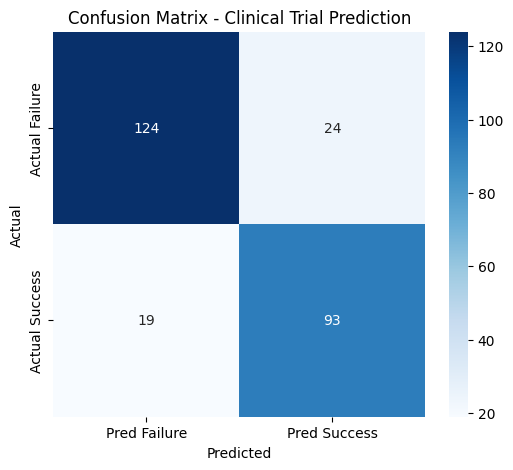

In [135]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Failure', 'Pred Success'],
            yticklabels=['Actual Failure', 'Actual Success'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Clinical Trial Prediction')
plt.show()

  Accuracy: 0.8346153846153846
  Precision: 0.7948717948717948
  Recall: 0.8303571428571429
  F1 score: 0.8122270742358079


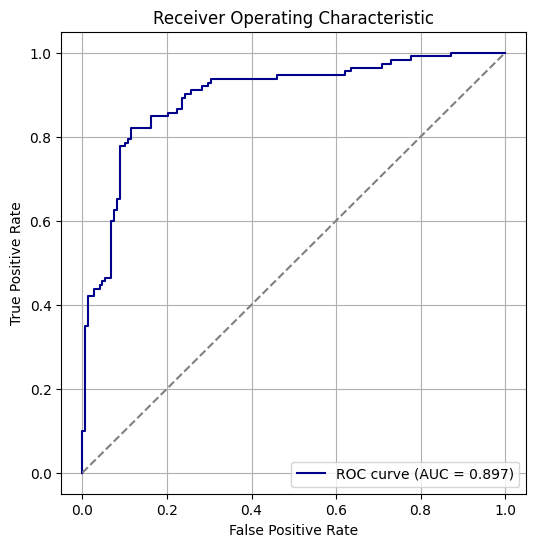

In [143]:
print("  Accuracy:", accuracy_score(y_test, y_pred))
print("  Precision:", precision_score(y_test, y_pred))
print("  Recall:", recall_score(y_test, y_pred))
print("  F1 score:", f1_score(y_test, y_pred))
if y_proba is not None:
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='darkblue', label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')  # diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Feature importance

## Model agnostic feature importance

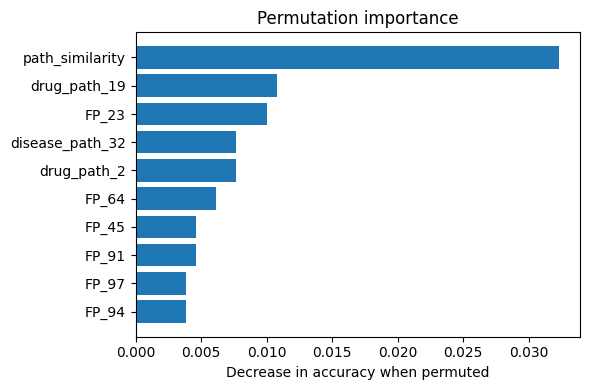

In [137]:
perm_imp = permutation_importance(estimator=model, X=X_test, y=y_test, n_repeats=5)

# Compute a dataframe to sum up the results
perm_importances = pd.DataFrame({
    "feature" : X.columns,
    "mean_importance" : perm_imp["importances_mean"],
    "std_importance" : perm_imp["importances_std"]
})
perm_importances.sort_values(by="mean_importance", ascending=False, inplace=True, ignore_index=True)
plt.figure(figsize=(6, 4))
plt.barh(perm_importances["feature"][:10][::-1], perm_importances["mean_importance"][:10][::-1])
plt.xlabel("Decrease in accuracy when permuted")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

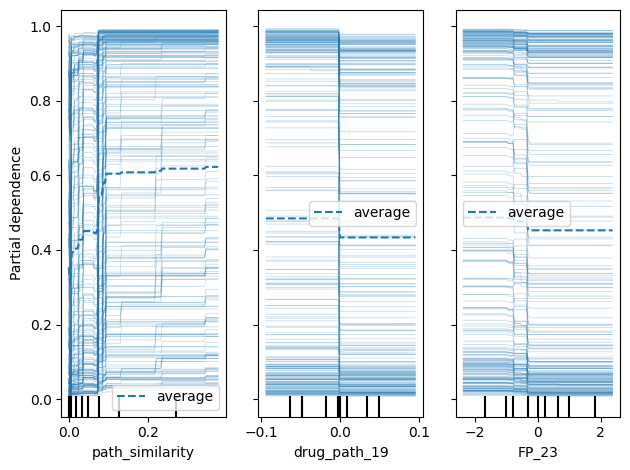

In [138]:
DO_2D_PDD = False # can be slow 

feature_to_plot = perm_importances["feature"][:3].tolist()
target_class = 1                        

PartialDependenceDisplay.from_estimator(
    estimator=model,
    X = X_test,
    target=target_class,
    features = feature_to_plot,
    kind="both"
)
plt.tight_layout()
plt.show()

if DO_2D_PDD:
    features_2d = [tuple(perm_importances["feature"][:2])]
    
    PartialDependenceDisplay.from_estimator(
        estimator=model,
        X = X_test,
        target=target_class,
        features=features_2d
    )
    plt.tight_layout()
    plt.show()


## Model-specific feature importance

In [139]:
num_features = list(num_cols)
cat_features = list(cat_cols)
all_features = num_features + cat_features

if "rf" in model.named_steps:
    rf = model.named_steps["rf"]

    
    importances = rf.feature_importances_
    rf_feature_importance = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    print(rf_feature_importance)
elif "logreg" in model.named_steps:
    logreg = model.named_steps["logreg"]
    coef = logreg.coef_[0]  
    logreg_feature_importance = pd.DataFrame({
        "feature": all_features,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values(by="abs_coef", ascending=False)

    print(logreg_feature_importance)

# TODO: PU / semi-supervized models 
# TODO: node2vec to generate features

# Heterogenous Graph Model

https://pytorch-geometric.readthedocs.io/en/2.6.0/notes/heterogeneous.html

Example schema:

```py
HeteroData(
  paper={
    x=[736389, 128],
    y=[736389],
    train_mask=[736389],
    val_mask=[736389],
    test_mask=[736389]
  },
  author={ x=[1134649, 128] },
  institution={ x=[8740, 128] },
  field_of_study={ x=[59965, 128] },
  (author, affiliated_with, institution)={ edge_index=[2, 1043998] },
  (author, writes, paper)={ edge_index=[2, 7145660] },
  (paper, cites, paper)={ edge_index=[2, 5416271] },
  (paper, has_topic, field_of_study)={ edge_index=[2, 7505078] }
)
```

Take data from:

- unique pathways from `drugs_df["drug_pathways"]`, `diseases_df["disease_pathways"]`
    - →  **pathway nodes**

- `drugs_df` 
    - →  **drug nodes**
    - →  feature vector: from `FP_...` and other non-path columns
    - →  **edges drug-pathway** from lists `drug_pathways`
    
- `diseases_df` 
    - →  **disease nodes**
    - →  feature vector: from non-path columns (probably none)
    - →  **edges disese-pathway** from lists `disease_pathways`

- `merged_df` 
    - →  **edges drug-disease** labeled by `success`

Nodes:

In [119]:
drugs_df = drugs_df.reset_index(drop=True)
diseases_df = diseases_df.reset_index(drop=True)
merged_df = merged_df.reset_index(drop=True)

In [120]:
drug_features = drugs_df.drop(columns = drugs_df.filter(regex="path").columns)
drug_features = drug_features.select_dtypes(include=["number", "bool"])
drug_features = torch.tensor( drug_features.values.astype(np.float64), dtype=torch.float)

disease_features = diseases_df.drop(columns = diseases_df.filter(regex="path").columns)
disease_features = disease_features.select_dtypes(include=["number", "bool"])
disease_features = torch.tensor( disease_features.values.astype(np.float64), dtype=torch.float)

all_pathways = np.array( list(set(drugs_df["drug_pathways"].explode()) | set(diseases_df["disease_pathways"].explode())), dtype=str)

Keep track of ROW ids:

In [121]:
path2id = {p: i for i, p in enumerate(all_pathways)}
drug2id = {row["drug_id"]:i for i, row in drugs_df.iterrows()}
disease2id = {row["disease_id"]:i for i, row in diseases_df.iterrows()}

Edges:

In [122]:
drug_pathway_edges = []
for _, row in drugs_df.iterrows():
    for path in row["drug_pathways"]:
        drug_id = drug2id[row["drug_id"]]
        path_id = path2id[path]
        drug_pathway_edges.append([drug_id, path_id])

drug_pathway_edges = torch.tensor(drug_pathway_edges, dtype=torch.long).t().contiguous()

disease_pathway_edges = []
for _, row in diseases_df.iterrows():
    for path in row["disease_pathways"]:
        disease_id = disease2id[row["disease_id"]]
        path_id = path2id[path]
        disease_pathway_edges.append([disease_id, path_id])

disease_pathway_edges = torch.tensor(disease_pathway_edges, dtype=torch.long).t().contiguous()

In [123]:
drug_disease_edges = []
drug_disease_edge_label = []

for _, row in merged_df.iterrows():
    drug_id = drug2id[row["drug_id"]]
    disease_id = disease2id[row["disease_id"]]
    drug_disease_edges.append([drug_id, disease_id])
    drug_disease_edge_label.append(int(row["success"]))


drug_disease_edges = torch.tensor(drug_disease_edges, dtype=torch.long).t().contiguous()

drug_disease_edge_label = torch.tensor(drug_disease_edge_label, dtype=torch.float)



Build the graph:

In [124]:
num_drugs = len(drugs_df)
num_diseases = len(diseases_df)
num_pathways = len(all_pathways)
num_trials = len(merged_df)

In [125]:
data = HeteroData()


data["drug"].x = drug_features
data["disease"].x = disease_features 
data["pathway"].x = torch.ones( (num_pathways, 1)) # dummy features

data['drug', 'interacts', 'pathway'].edge_index = drug_pathway_edges
data['disease', 'associated_with', 'pathway'].edge_index = disease_pathway_edges
data['drug', 'tryed_against', 'disease'].edge_index = drug_disease_edges
data['drug', 'tryed_against', 'disease'].edge_label = drug_disease_edge_label

data


HeteroData(
  drug={ x=[742, 127] },
  disease={ x=[167, 24] },
  pathway={ x=[1509, 1] },
  (drug, interacts, pathway)={ edge_index=[2, 31266] },
  (disease, associated_with, pathway)={ edge_index=[2, 13608] },
  (drug, tryed_against, disease)={
    edge_index=[2, 1298],
    edge_label=[1298],
  }
)

### GNN edge-level prediction

In [126]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensures that the CUDA convolution operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#### Preprocessing:

In [127]:
# We need to add reverse edges for the auxiliary types so messages flow 
# bi-directionally (e.g. Pathway -> Drug).
# We EXCLUDE the target edge type ('tryed_against') from message passing 
# to prevent data leakage (predicting label using the label itself).
transform = T.AddMetaPaths(
    metapaths=[
        [('drug', 'interacts', 'pathway'), ('pathway', 'rev_interacts', 'drug')],
        [('disease', 'associated_with', 'pathway'), ('pathway', 'rev_associated_with', 'disease')]
    ],
    drop_orig_edge_types=False, # Keep original edges
    drop_unconnected_node_types=False
)
# Note: For simplicity in this minimal example, we will manually add reverse edges below
# instead of complex transforms to keep it readable.

# Simple manual reverse edge addition for message passing:
data['pathway', 'rev_interacts', 'drug'].edge_index = data['drug', 'interacts', 'pathway'].edge_index.flip([0])
data['pathway', 'rev_associated', 'disease'].edge_index = data['disease', 'associated_with', 'pathway'].edge_index.flip([0])

# Split target edges into Train/Test
# We use a simple mask approach on the edge_label
indices = torch.randperm(num_trials)
train_idx = indices[:int(0.8*num_trials)]
test_idx = indices[int(0.8*num_trials):]

#### Model:

In [128]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # SAGEConv is general purpose. -1 lets PyG infer input dimensions.
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

class LinkClassifier(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels):
        super().__init__()
        # Instantiate the GNN
        self.gnn = GNN(hidden_channels, out_channels)
        # Convert GNN to HeteroGNN (automatically handles different node/edge types)
        self.gnn = to_hetero(self.gnn, metadata, aggr='sum')
        
        # Final classifier: Concatenate Drug + Disease embeddings -> Probability
        self.classifier = torch.nn.Linear(out_channels * 2, 1)

    def forward(self, data):
        # 1. Message Passing: Get embeddings for all nodes
        # We only pass the message passing edges, NOT the target edges
        x_dict = self.gnn(data.x_dict, data.edge_index_dict)
        
        # 2. Edge Prediction
        # Get embeddings for the source (drug) and target (disease) of the trials
        edge_index = data['drug', 'tryed_against', 'disease'].edge_index
        src, dst = edge_index
        
        feat_drug = x_dict['drug'][src]
        feat_disease = x_dict['disease'][dst]
        
        # Concatenate and classify
        x = torch.cat([feat_drug, feat_disease], dim=-1)
        return self.classifier(x).squeeze()

#### Training loop:

In [129]:
N_EPOCHS = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
model = LinkClassifier(data.metadata(), hidden_channels=32, out_channels=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# Calculate weights based on your training labels
labels = data['drug', 'tryed_against', 'disease'].edge_label[train_idx]
num_pos = labels.sum()
num_neg = len(labels) - num_pos

# Weight = (Number of Negatives) / (Number of Positives)
# If you have 10x more failures than successes, pos_weight will be 10.0
pos_weight = torch.tensor([num_neg / num_pos]).to(device)


print("Starting training...")

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    
    # Forward Pass
    out = model(data) # Output logits for ALL 'tryed_against' edges
    
    # Calculate balanced Loss only on Training indices

    loss = F.binary_cross_entropy_with_logits(
        out[train_idx], 
        data['drug', 'tryed_against', 'disease'].edge_label[train_idx],
        pos_weight=pos_weight # This tells the model "Successes are X times more important"
    )
    
    loss.backward()
    optimizer.step()
    
    # Evaluation
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            out = model(data)
            pred = (out.sigmoid() > 0.5).float()
            
            # Calculate Test Accuracy
            correct = (pred[test_idx] == data['drug', 'tryed_against', 'disease'].edge_label[test_idx]).sum()
            acc = int(correct) / len(test_idx)
            print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}')

Starting training...
Epoch 000, Loss: 2.2371, Test Acc: 0.6000
Epoch 020, Loss: 0.8404, Test Acc: 0.4000
Epoch 040, Loss: 0.6547, Test Acc: 0.7654
Epoch 060, Loss: 0.5436, Test Acc: 0.7654
Epoch 080, Loss: 0.4938, Test Acc: 0.7731


#### Final evaluation:

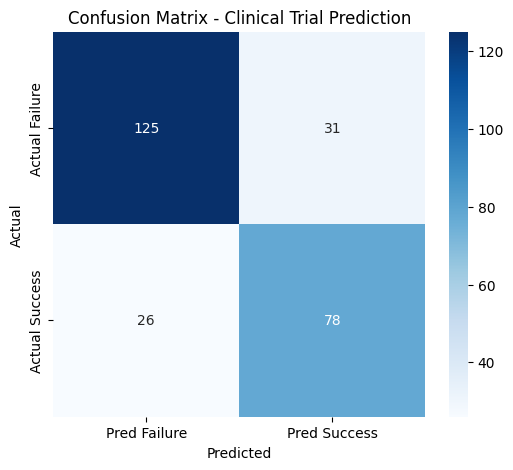

In [130]:
model.eval()
with torch.no_grad():
    # 1. Get Model Output
    out = model(data)
    
    # 2. Convert logits to probabilities and then to binary class predictions (0 or 1)
    pred = (out.sigmoid() > 0.5).float()
    
    y_true = data['drug', 'tryed_against', 'disease'].edge_label[test_idx].cpu().numpy()
    y_pred = pred[test_idx].cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred Failure', 'Pred Success'],
                yticklabels=['Actual Failure', 'Actual Success'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix - Clinical Trial Prediction')
    plt.show()
